# Zomato Restaurant Performance Analysis and Prediction

## Introduction

This project analyzes a Hyderabad Zomato restaurant dataset to understand and predict restaurant performance using exploratory data analysis, statistical techniques, and machine learning. The project includes data cleaning, visualization, restaurant segmentation, hypothesis testing, and predictive modeling using Logistic Regression. Key features such as ratings, votes, pricing, dining experience, and customer engagement were analyzed to identify patterns in restaurant quality and predict underperforming (Weak) restaurants. Insights from the project help understand restaurant behavior across segments such as Hidden Gems, Top Performers, Overhyped, and Weak restaurants, supporting better business and recommendation decisions.


## 1.Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2.Loading and Exploring the Dataset

In [2]:
#Load dataset
df=pd.read_csv('Zomato_data.csv')

#View first 5 rows
print(df.head())

#View last 5 rows
print(df.tail())


#Rename column
df.rename(columns={
    'Restaurant_Name': 'restaurant_name',
    'Dining_Rating': 'dining_rating',
    'Delivery_Rating': 'delivery_rating',
    'Dining_Votes': 'dining_votes',
    'Delivery_Votes': 'delivery_votes',
    'Cuisine':'cuisine',
    'Place_Name': 'place',
    'City':'city',
    'Item_Name': 'item_name',
    'Best_Seller': 'best_seller',
    'Is_Bestseller': 'is_bestseller',
    'Restaurant_Popularity': 'restaurant_popularity',
    'Avg_Rating_Restaurant': 'avg_rating_restaurant',
    'Avg_Price_Restaurant': 'avg_price_restaurant',
    'Avg_Rating_Cuisine': 'avg_rating_cuisine',
    'Avg_Price_Cuisine': 'avg_price_cuisine',
    'Avg_Rating_City': 'avg_rating_city',
    'Avg_Price_City': 'avg_price_city',
    'Is_Highly_Rated': 'is_highly_rated',
    'Is_Expensive': 'is_expensive',
    'Votes':'votes',
    'Average_Rating': 'avg_rating',
    'Prices': 'price',
    'Total_Votes': 'total_votes',
    'Price_per_Vote': 'price_per_vote',
    'log_price': 'log_price'
}, inplace=True)

#Dataset info
df.info()

#Descriptive statistics for numerical columns
df.describe()

  Restaurant_Name  Dining_Rating  Delivery_Rating  Dining_Votes  \
0      Doner King            3.9              4.2            39   
1      Doner King            3.9              4.2            39   
2      Doner King            3.9              4.2            39   
3      Doner King            3.9              4.2            39   
4      Doner King            3.9              4.2            39   

   Delivery_Votes    Cuisine Place_Name        City                 Item_Name  \
0               0  Fast Food   Malakpet   Hyderabad       Platter Kebab Combo   
1               0  Fast Food   Malakpet   Hyderabad   Chicken Rumali Shawarma   
2               0  Fast Food   Malakpet   Hyderabad    Chicken Tandoori Salad   
3               0  Fast Food   Malakpet   Hyderabad         Chicken BBQ Salad   
4               0  Fast Food   Malakpet   Hyderabad  Special Doner Wrap Combo   

  Best_Seller  ...  Is_Bestseller  Restaurant_Popularity  \
0  BESTSELLER  ...              1                 

,dining_rating,delivery_rating,dining_votes,delivery_votes,votes,price,avg_rating,total_votes,price_per_vote,Log_Price,is_bestseller,restaurant_popularity,avg_rating_restaurant,avg_price_restaurant,avg_rating_cuisine,avg_price_cuisine,avg_rating_city,avg_price_city,is_highly_rated,is_expensive
count,123657.000000,123657.000000,123657.000000,123657.000000,123657.000000,123657.000000,123657.000000,123657.000000,123657.000000,123657.000000,123657.0,123657.000000,123657.000000,123657.000000,123657.000000,123657.000000,123657.000000,123657.000000,123657.000000,123657.000000
mean,3.822264,3.963184,152.729858,115.763725,24.666772,241.378399,3.892724,268.493583,154.707246,5.265611,1.0,304.008143,3.892724,241.378399,3.892724,241.378399,3.892724,241.378399,0.373970,0.243464
std,0.351407,0.244624,232.214061,243.970828,125.236009,192.830713,0.238449,292.811830,207.522162,0.699109,0.0,346.309371,0.229933,94.690020,0.074554,30.359509,0.025634,29.121965,0.483858,0.429174
min,2.500000,2.500000,0.000000,0.000000,0.000000,0.950000,3.000000,0.000000,0.006586,0.667829,1.0,4.000000,3.000000,35.833333,3.406122,61.428571,3.600000,194.591645,0.000000,0.000000
25%,3.700000,3.800000,0.000000,0.000000,0.000000,130.000000,3.750000,11.000000,11.000000,4.875197,1.0,125.000000,3.750000,178.460526,3.873352,212.572315,3.880503,223.676576,0.000000,0.000000
50%,3.822264,4.000000,30.000000,0.000000,0.000000,208.570000,3.911132,158.000000,95.000000,5.345058,1.0,195.000000,3.911132,230.959514,3.913401,254.565364,3.889413,235.550603,0.000000,0.000000
75%,4.000000,4.100000,217.000000,23.000000,15.000000,299.000000,4.050000,447.000000,245.000000,5.703782,1.0,318.000000,4.050000,285.146825,3.928624,255.954894,3.907014,245.130482,1.000000,0.000000
max,4.800000,4.600000,997.000000,983.000000,9750.000000,12024.000000,4.650000,1393.000000,12024.000000,9.394743,1.0,2059.000000,4.450000,1011.718750,4.250000,512.500000,4.000000,670.242424,1.000000,1.000000


In [6]:
df['City'].unique()

array([' Hyderabad', ' Mumbai', ' Chennai', ' Pune', ' Jaipur', ' Kochi',
       ' Goa', ' Bangalore', ' Kolkata', ' Ahmedabad', ' Banaswadi',
       ' Ulsoor', ' Malleshwaram', ' Magrath Road', ' Lucknow',
       ' New Delhi', ' Raipur'], dtype=object)

## 3.Data Cleaning

In [37]:
#Filter Hyderabad Restaurants
df_hyd = df[df['city'].str.strip() == 'Hyderabad'].copy()

# convert Categorical Columns
cat_cols = [
    'city',
    'place',
    'cuisine',
    'is_bestseller',
    'is_highly_rated',
    'is_expensive',
    'best_seller'
]

for col in cat_cols:
    df_hyd[col] = df_hyd[col].astype('category')

# Check Missing Values and Duplicates
df_hyd.isnull().sum()

df_hyd.duplicated().sum()

df_hyd[df_hyd.duplicated()]   
 

# Identify Problematic Text Rows
problem_rows = df_hyd[df_hyd.astype(str).apply(
    lambda x: x.str.contains(r'^\s|\s$|"', regex=True)
).any(axis=1)]

print("Problematic rows before fix:", problem_rows.shape[0])

# Clean Text Columns
text_cols = df_hyd.select_dtypes(include='object').columns

for col in text_cols:
    df_hyd[col] = df_hyd[col].astype(str).str.strip()
    df_hyd[col] = df_hyd[col].str.replace(r'\s+', ' ', regex=True)
    df_hyd[col] = df_hyd[col].str.replace('"', "'", regex=True)
    
# Handle Empty Strings
df_hyd.replace("", np.nan, inplace=True)

# Validate Cleaning Results
new_problem_rows = df_hyd[df_hyd.astype(str).apply(
    lambda x: x.str.contains(r'^\s|\s$|"', regex=True)
).any(axis=1)]
print("Problematic rows after fix:", new_problem_rows.shape[0])

df_hyd.describe()

Problematic rows before fix: 15613
Problematic rows after fix: 15613


,dining_rating,delivery_rating,dining_votes,delivery_votes,votes,price,avg_rating,total_votes,price_per_vote,Log_Price,restaurant_popularity,avg_rating_restaurant,avg_price_restaurant,avg_rating_cuisine,avg_price_cuisine,avg_rating_city,avg_price_city
count,15613.000000,15613.000000,15613.000000,15613.000000,15613.000000,15613.000000,15613.000000,15613.000000,15613.000000,15613.000000,15613.000000,15613.000000,15613.000000,15613.000000,15613.000000,1.561300e+04,1.561300e+04
mean,3.878013,4.000049,132.230705,103.054186,51.403958,245.130482,3.939031,235.284891,147.758976,5.267843,261.190482,3.936993,245.309399,3.905915,247.266949,3.939031e+00,2.451305e+02
std,0.363562,0.213004,216.326288,247.589996,281.382343,200.379612,0.219505,292.202786,213.216833,0.709620,308.271865,0.201712,103.866891,0.076627,24.268869,9.357259e-13,6.463304e-11
min,2.700000,3.200000,0.000000,0.000000,0.000000,0.950000,3.200000,0.000000,0.007106,0.667829,5.000000,3.350000,79.166667,3.406122,164.525510,3.939031e+00,2.451305e+02
25%,3.800000,3.900000,0.000000,0.000000,0.000000,130.000000,3.811132,0.000000,7.000000,4.875197,119.000000,3.779224,180.764706,3.873352,239.902978,3.939031e+00,2.451305e+02
50%,3.900000,4.000000,19.000000,0.000000,0.000000,209.000000,3.961132,116.000000,63.000000,5.347108,184.000000,3.961132,226.307018,3.928624,254.565364,3.939031e+00,2.451305e+02
75%,4.200000,4.100000,162.000000,0.000000,23.000000,299.000000,4.100000,338.000000,235.000000,5.703782,267.000000,4.100000,288.598870,3.928624,260.363492,3.939031e+00,2.451305e+02
max,4.600000,4.600000,997.000000,975.000000,9750.000000,3250.000000,4.450000,1393.000000,3250.000000,8.086718,2059.000000,4.450000,1011.718750,4.100000,318.322826,3.939031e+00,2.451305e+02


In [26]:
df_hyd.columns

Index(['restaurant_name', 'dining_rating', 'delivery_rating', 'dining_votes',
       'delivery_votes', 'cuisine', 'place', 'city', 'item_name',
       'best_seller', 'votes', 'price', 'avg_rating', 'total_votes',
       'price_per_vote', 'Log_Price', 'is_bestseller', 'restaurant_popularity',
       'avg_rating_restaurant', 'avg_price_restaurant', 'avg_rating_cuisine',
       'avg_price_cuisine', 'avg_rating_city', 'avg_price_city',
       'is_highly_rated', 'is_expensive'],
      dtype='object')

## 4.Feature Engineering 

In [4]:
# Define Thresholds
low_votes_threshold = df_hyd['total_votes'].quantile(0.25)
high_votes_threshold = df_hyd['total_votes'].quantile(0.75)
high_rating_threshold = 4.0

In [5]:
#Create Restaurant Segment Feature
#weak
df_hyd['segment'] = 'weak'

# Top Performers
df_hyd.loc[
    (df_hyd['avg_rating'] >= high_rating_threshold) &
    (df_hyd['total_votes'] >= high_votes_threshold),
    'segment'
] = 'top_performers'

# Hidden Gems
df_hyd.loc[
    (df_hyd['avg_rating'] >= high_rating_threshold) &
    (df_hyd['total_votes'] <= low_votes_threshold),
    'segment'
] = 'hidden_gems'

# Overhyped Restaurants
df_hyd.loc[
    (df_hyd['avg_rating'] < high_rating_threshold) &
    (df_hyd['total_votes'] >= high_votes_threshold),
    'segment'
] = 'overhyped'

## 5.Exploratory Data Analysis (EDA)

### 1.Descriptive Statistics

In [6]:
# Summary of Key Numerical Features
summary_stats=df_hyd[['avg_rating', 'price', 'total_votes']].describe() 
print(summary_stats)

         avg_rating         price   total_votes
count  15613.000000  15613.000000  15613.000000
mean       3.939031    245.130482    235.284891
std        0.219505    200.379612    292.202786
min        3.200000      0.950000      0.000000
25%        3.811132    130.000000      0.000000
50%        3.961132    209.000000    116.000000
75%        4.100000    299.000000    338.000000
max        4.450000   3250.000000   1393.000000


### 2.Correlation Analysis

In [7]:
# Rating vs Price Correlation
corr_rating_price=df_hyd[['avg_rating', 'price']].corr()
print(corr_rating_price)

            avg_rating     price
avg_rating    1.000000  0.033606
price         0.033606  1.000000


**Interpretation**:
There is a very weak positive correlation (0.03) between price and rating, indicating that higher-priced restaurants do not necessarily receive higher ratings.
 This suggests that customer satisfaction is driven by factors beyond price, such as food quality, service, and experience.

In [8]:
# Rating vs Votes Correlation
corr_rating_votes=df_hyd[['total_votes', 'avg_rating']].corr()
print(corr_rating_votes)

             total_votes  avg_rating
total_votes     1.000000   -0.017147
avg_rating     -0.017147    1.000000


**Interpretation**:The correlation between total votes and average rating is almost zero (-0.017), indicating no meaningful linear relationship between customer engagement and restaurant ratings.
 This suggests that the number of votes is not a reliable indicator of restaurant quality or customer satisfaction in this dataset

### 3.Cuisine Analysis

In [9]:
# Cuisine Frequency
cuisine_count=df_hyd['cuisine'].value_counts()
print(cuisine_count)

cuisine
Beverages       5391
Desserts        2613
Fast Food       1584
Chinese          977
North Indian     842
Biryani          694
Bakery           434
Ice Cream        379
Shake            345
Mandi            324
Mughlai          317
Pizza            260
Rolls            233
Kebab            231
Seafood          217
Burger           136
Wraps            136
Coffee           135
Momos            119
Hyderabadi       105
South Indian      68
Shawarma          51
Turkish           22
Name: count, dtype: int64


In [10]:
# Cuisine Performance Summary
cuisine_summary=df_hyd.groupby('cuisine',observed=True)[['avg_rating', 'total_votes', 'price']].mean().sort_values(by='avg_rating', ascending=False)
print(cuisine_summary)

              avg_rating  total_votes       price
cuisine                                          
Turkish         4.100000   907.000000  244.090909
Wraps           4.086029   151.125000  187.886544
Desserts        4.023552   229.630693  273.329659
Hyderabadi      4.000000    19.000000  184.800000
North Indian    3.993239   345.491686  201.699525
Bakery          3.992362    76.672811  148.850230
Beverages       3.990891   179.330551  255.851577
Mandi           3.963753   599.660494  245.535710
South Indian    3.950000   997.000000   89.485294
Pizza           3.936763   425.076923  157.327308
Ice Cream       3.934565   279.142480  140.088786
Rolls           3.923434     4.789700  280.890858
Biryani         3.920602   271.329971  307.535187
Kebab           3.898701   362.805195  313.865801
Fast Food       3.894641   265.799242  261.005739
Chinese         3.889904   308.342886  228.549642
Momos           3.861132   111.000000  154.201681
Shawarma        3.850000    44.000000  180.764706


**Interpretation**:Cuisine-wise analysis shows that average ratings vary within a narrow range (3.2 to 4.1), indicating that most cuisines maintain moderate to good customer satisfaction rather than extreme differences.
 However, engagement (votes) and pricing differ significantly across cuisines, showing that popularity and cost are not strongly aligned with ratings. Some cuisines have high ratings but low engagement, while others have high engagement but comparatively lower ratings.

### 4.Restaurant Segment Analysis

In [11]:
# Segment Distribution
segment_distribution=df_hyd['segment'].value_counts()
print(segment_distribution)

segment
weak              8289
hidden_gems       3198
top_performers    2257
overhyped         1869
Name: count, dtype: int64


In [12]:
# Segment Performance
segment_performance_summary = (
    df_hyd.groupby('segment')[['avg_rating', 'total_votes', 'price']]
    .agg(['mean', 'median', 'std'])
)

print(segment_performance_summary)

               avg_rating                     total_votes                     \
                     mean    median       std        mean median         std   
segment                                                                        
hidden_gems      4.116387  4.100000  0.098004    0.000000    0.0    0.000000   
overhyped        3.774274  3.850000  0.251227  676.829856  625.0  209.929997   
top_performers   4.087145  4.061132  0.106275  658.653079  692.0  202.835517   
weak             3.867425  3.900000  0.200986  111.223067  111.0  100.855120   

                     price                     
                      mean median         std  
segment                                        
hidden_gems     283.427095  235.0  224.179848  
overhyped       257.914981  250.0  193.088359  
top_performers  250.121272  220.0  176.312437  
weak            226.113592  185.0  195.989536  


**Interpretation**:
The segment analysis shows clear behavioral differences among restaurant categories. Top performers achieved high average ratings (4.09) along with the highest customer engagement, averaging nearly 659 votes, indicating both quality and popularity. Overhyped restaurants received similarly high vote counts despite lower average ratings (3.77), suggesting strong visibility but weaker customer satisfaction.

Hidden gems maintained the highest average rating (4.12) but recorded almost no votes, meaning they are highly rated yet under-recognized by customers. Weak restaurants showed moderate ratings and low engagement, with lower average pricing compared to premium-performing segments.

Price analysis indicates that hidden gems tend to be relatively expensive despite limited visibility, while top performers balance strong ratings, high engagement, and competitive pricing. Overall, customer engagement appears strongly associated with restaurant popularity and perceived quality.


### 5.Dining vs Delivery Rating Analysis

In [36]:
# Dining vs Delivery Rating Comparison
dining_delivery_comparison=df_hyd.groupby('segment')[['dining_rating','delivery_rating']].mean()
print(dining_delivery_comparison)

                dining_rating  delivery_rating
segment                                       
hidden_gems          4.142342         4.090432
overhyped            3.560854         3.987694
top_performers       4.112127         4.062162
weak                 3.783798         3.951052


**Interpretation**:
Hidden Gems show consistently high ratings in both dining (4.14) and delivery (4.09), meaning they provide good overall experience, especially in dining, but they are not widely discovered or used.

Top Performers have almost identical and stable ratings in both dining (4.11) and delivery (4.06), showing they deliver a balanced and consistently good experience across both channels.

Overhyped restaurants show a strong gap where dining rating is low (3.56) but delivery rating is much higher (3.98), suggesting that they perform better in delivery than actual in-restaurant experience.

Weak restaurants have low ratings in both dining (3.78) and delivery (3.95), indicating generally poor performance, with slightly better experience in delivery but still overall weak quality

## 6.Data Visulization

### 1.Price vs Avearge Rating(Scatter chart)

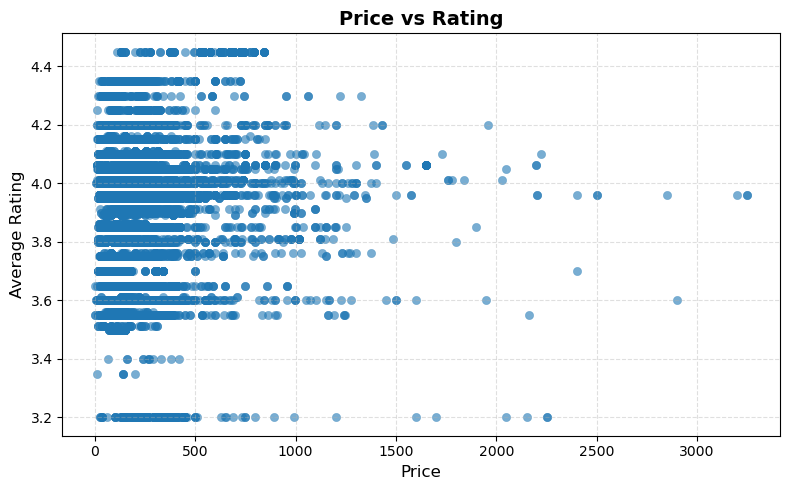

In [14]:
import matplotlib.pyplot as plt

#Create figure for scatter plot
plt.figure(figsize=(8,5))

#Plot scatter chart showing relationship between price and average rating
plt.scatter(
    df_hyd['price'],
    df_hyd['avg_rating'],
    
    #Set transparency for overlapping points
    alpha=0.6,
    
    #Set point border thickness
    linewidth=0.3
)

#Add chart title
plt.title('Price vs Rating', fontsize=14, fontweight='bold')

#Add x-axis label
plt.xlabel('Price', fontsize=12)

#Add y-axis label
plt.ylabel('Average Rating', fontsize=12)

#Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.4)

#Adjust layout spacing
plt.tight_layout()

#Display the chart
plt.show()



**Interpretation**:
Restaurants priced below ₹1500 show a wide spread of ratings, ranging from around 3.2 to above 4.2. However, a large concentration of restaurants in this range fall between 3.5 and 4.2, indicating generally moderate to good customer satisfaction with some variability.

For the ₹1500–₹3000 range, the number of restaurants is much lower, and only a few achieve ratings above 4. This makes the trend less stable, but it suggests that higher pricing does not consistently guarantee higher ratings.

### 2.Votes vs Rating Analysis

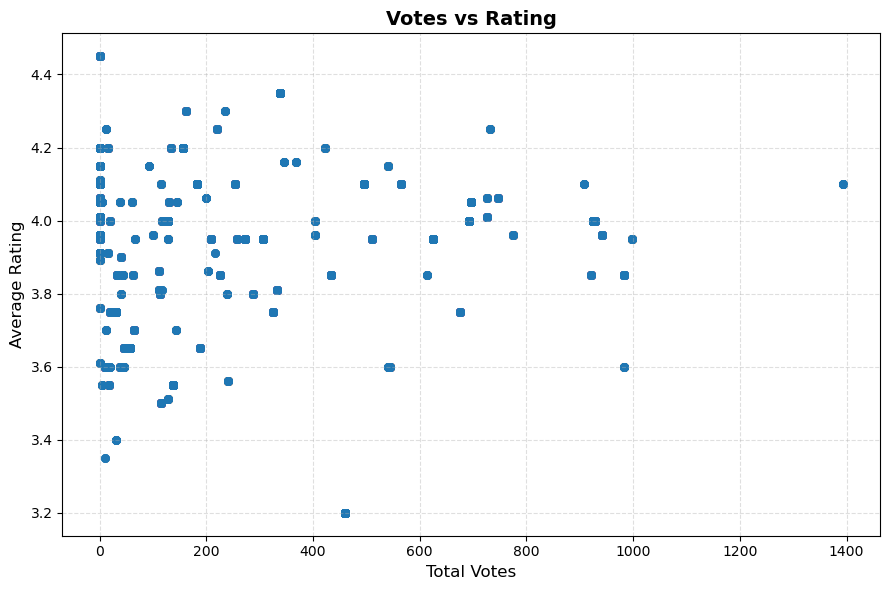

In [15]:
import matplotlib.pyplot as plt

#Create figure for scatter plot
plt.figure(figsize=(9,6))

#Plot scatter chart showing relationship between total votes and average rating
plt.scatter(
    df_hyd['total_votes'],
    df_hyd['avg_rating'],
    
    #Set transparency for overlapping points
    alpha=0.6,
    
    #Set point border thickness
    linewidth=0.3
)

#Add chart title
plt.title('Votes vs Rating', fontsize=14, fontweight='bold')

#Add x-axis label
plt.xlabel('Total Votes', fontsize=12)

#Add y-axis label
plt.ylabel('Average Rating', fontsize=12)

#Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.4)

#Adjust layout spacing
plt.tight_layout()

#Display the chart
plt.show()


**Interpretation**:
Total votes are distributed from 0 to around 1400, with the majority of restaurants concentrated below 1000 votes.

Within this range, most restaurants have ratings between 3.5 and above 4.2, indicating that moderate to high-rated restaurants dominate the dataset.

For very high vote counts (above 1000), there are very few data points, with only a single observation around 4.1 rating, showing that extremely popular restaurants are rare in this dataset.

### 3.Average Rating by Restaurant Segment

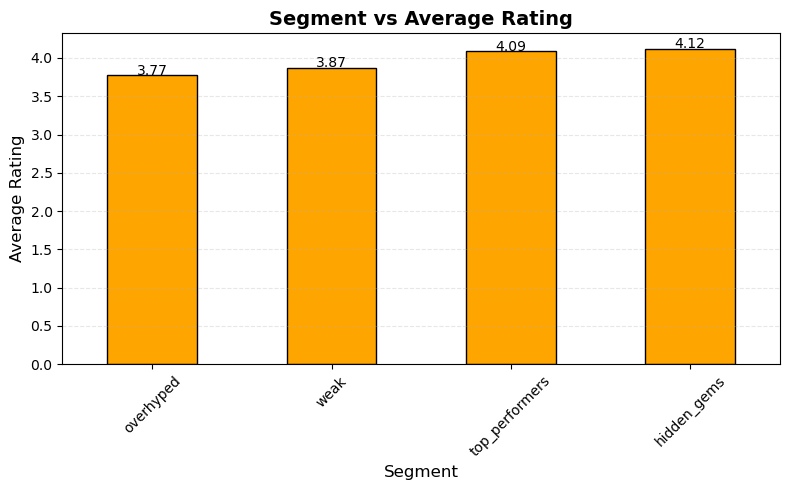

In [16]:
import matplotlib.pyplot as plt

#Calculate average rating for each restaurant segment
segment_rating = df_hyd.groupby('segment')['avg_rating'].mean().sort_values()

#Create figure for bar chart
plt.figure(figsize=(8,5))

#Plot bar chart showing average rating by segment
segment_rating.plot(
    kind='bar',
    
    #Set bar color
    color='orange',
    
    #Set bar border color
    edgecolor='black'
)

#Add chart title
plt.title('Segment vs Average Rating', fontsize=14, fontweight='bold')

#Add x-axis label
plt.xlabel('Segment', fontsize=12)

#Add y-axis label
plt.ylabel('Average Rating', fontsize=12)

#Add value labels above bars
for i, v in enumerate(segment_rating.values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=10)

#Add horizontal grid for readability
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

#Rotate x-axis labels
plt.xticks(rotation=45)

#Adjust layout spacing
plt.tight_layout()

#Display the chart
plt.show()


**Interpretation**:Hidden Gems (4.11) and Top Performers (4.08) show the highest average ratings, indicating strong and consistent customer satisfaction.
Weak segment (3.86) has moderate ratings, showing average performance.
Overhyped segment (3.77) has the lowest ratings, suggesting lower customer satisfaction despite visibility.
Overall, there is a clear performance gap between high-performing and low-performing restaurant segments.

### 4.Average Customer Votes Across Restaurant Segments

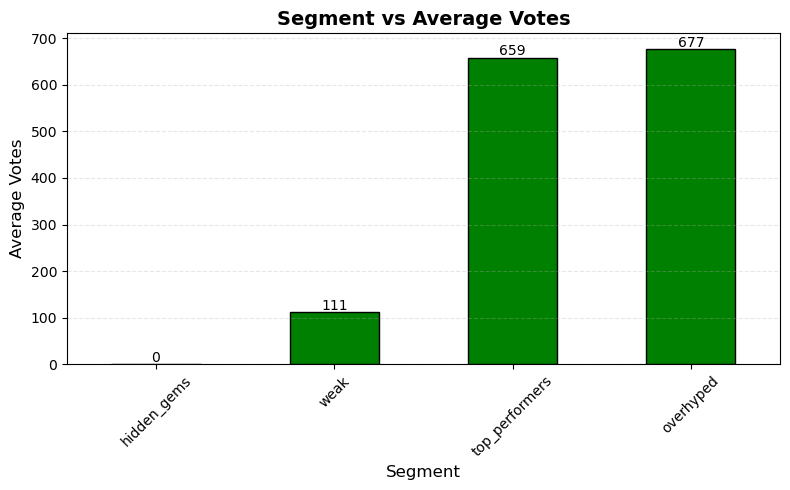

In [17]:

import matplotlib.pyplot as plt

#Calculate average customer votes for each restaurant segment
segment_votes = df_hyd.groupby('segment')['total_votes'].mean().sort_values()

#Create figure for bar chart
plt.figure(figsize=(8,5))

#Plot bar chart showing average votes by segment
segment_votes.plot(
    kind='bar',
    
    #Set bar color
    color='green',
    
    #Set bar border color
    edgecolor='black'
)

#Add chart title
plt.title('Segment vs Average Votes', fontsize=14, fontweight='bold')

#Add x-axis label
plt.xlabel('Segment', fontsize=12)

#Add y-axis label
plt.ylabel('Average Votes', fontsize=12)

#Add value labels above bars
for i, v in enumerate(segment_votes.values):
    plt.text(i, v + 5, f"{v:.0f}", ha='center', fontsize=10)

#Add horizontal grid for readability
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

#Rotate x-axis labels
plt.xticks(rotation=45)

#Adjust layout spacing
plt.tight_layout()

#Display the chart
plt.show()


**Interpretation**:
Top Performers (658 votes) show the highest engagement, indicating strong popularity and customer trust.
Overhyped (676 votes) also have high engagement, but earlier lower ratings suggest popularity doesn’t always match satisfaction.
Weak segment (111 votes) has low engagement, showing limited customer reach.
Hidden Gems (0 votes) have no engagement data despite high ratings, meaning they are high-quality but not discovered.

### 5.Dining vs Delivery Rating Comparison Across Restaurant Segments

<Figure size 1000x500 with 0 Axes>

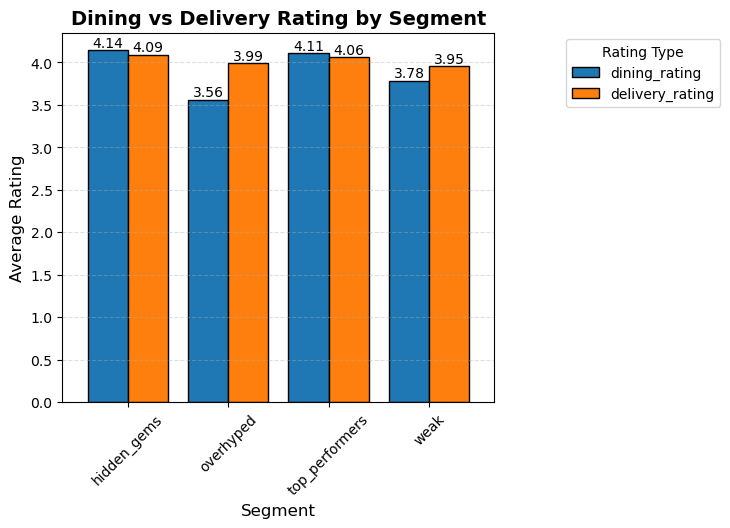

In [35]:
import matplotlib.pyplot as plt

#Calculate average dining and delivery ratings for each restaurant segment
segment_compare = df_hyd.groupby('segment')[['dining_rating', 'delivery_rating']].mean()

#Create figure for grouped bar chart
plt.figure(figsize=(10,5))

#Plot grouped bar chart comparing dining and delivery ratings
ax = segment_compare.plot(
    kind='bar',
    
    #Set bar border color
    edgecolor='black',
    
    #Set bar width
    width=0.8
)

#Add chart title
plt.title('Dining vs Delivery Rating by Segment', fontsize=14, fontweight='bold')

#Add x-axis label
plt.xlabel('Segment', fontsize=12)

#Add y-axis label
plt.ylabel('Average Rating', fontsize=12)

#Add horizontal grid for readability
plt.grid(True, linestyle='--', alpha=0.4, axis='y')

#Place legend outside chart for better visibility
plt.legend(
    title='Rating Type',
    bbox_to_anchor=(1.15, 1),
    loc='upper left'
)

#Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=10)

#Adjust layout spacing for legend
plt.subplots_adjust(right=0.8)

#Rotate x-axis labels
plt.xticks(rotation=45)

#Display the chart
plt.show()

**Interpretation**:
Hidden Gems show slightly higher dining rating (4.14) than delivery (4.09), indicating slightly better in-restaurant experience.
Top Performers have balanced ratings (4.11 dining, 4.06 delivery), showing consistent performance across both channels.
Overhyped shows a noticeable gap (dining 3.56 vs delivery 3.99), meaning delivery experience is better than dining perception.
Weak segment has lower ratings overall (3.78 dining, 3.95 delivery), but delivery is still slightly better than dining.

### 6.Restaurant Segment distribution

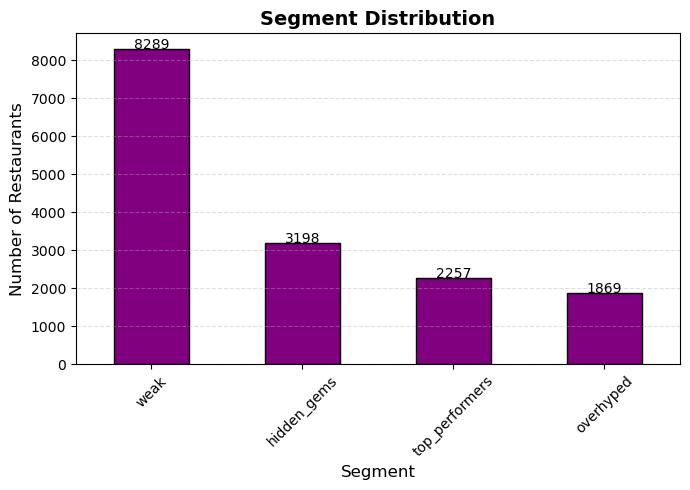

In [31]:
import matplotlib.pyplot as plt

#Calculate number of restaurants in each segment
segment_counts = df_hyd['segment'].value_counts()

#Create figure for bar chart
plt.figure(figsize=(7,5))

#Plot bar chart showing segment distribution
ax = segment_counts.plot(
    kind='bar',
    
    #Set bar color
    color='purple',
    
    #Set bar border color
    edgecolor='black'
)

#Add chart title
plt.title('Segment Distribution', fontsize=14, fontweight='bold')

#Add x-axis label
plt.xlabel('Segment', fontsize=12)

#Add y-axis label
plt.ylabel('Number of Restaurants', fontsize=12)

#Add horizontal grid for readability
plt.grid(True, linestyle='--', alpha=0.4, axis='y')

#Add value labels above bars
for i, v in enumerate(segment_counts.values):
    plt.text(i, v + 2, str(v), ha='center', fontsize=10)

#Rotate x-axis labels
plt.xticks(rotation=45)

#Adjust layout spacing
plt.tight_layout()

#Display the chart
plt.show()


**Interpretation**:
the Weak segment (8289 restaurants) is the largest group, showing that a major portion of restaurants fall under lower performance in terms of ratings and engagement.
The Hidden Gems segment (3198 restaurants) is the second largest, indicating a significant number of high-quality restaurants that are not highly popular or widely discovered.
The Top Performers (2257 restaurants) represent a smaller but strong group of consistently well-performing restaurants with good ratings and engagement.
The Overhyped segment (1869 restaurants) is the smallest group, suggesting fewer restaurants attract high attention but do not translate it into strong performance.

### 7.Most Popular Cuisines Based on Customer Engagement

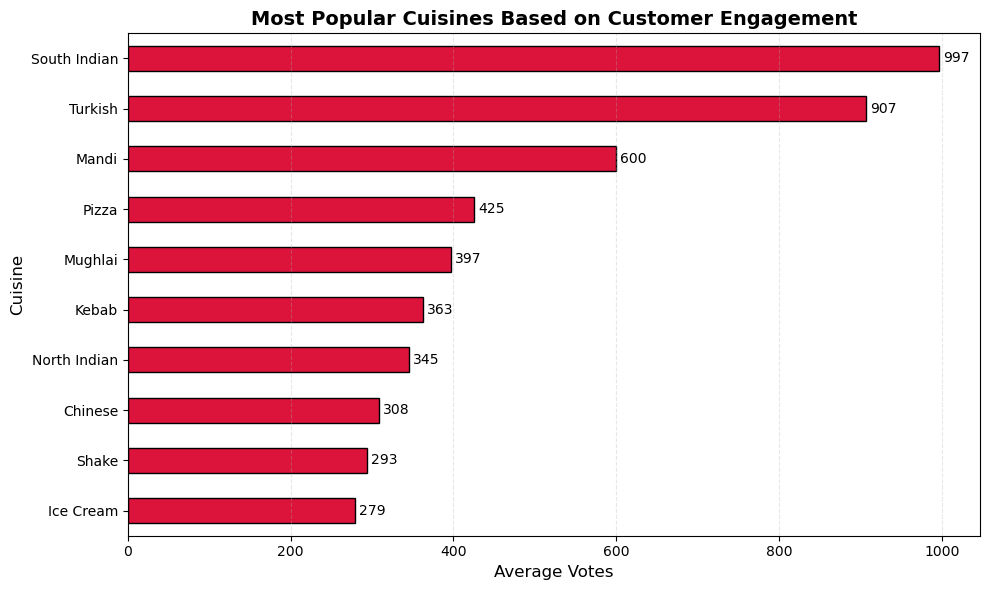

In [18]:
import matplotlib.pyplot as plt

#Calculate top 10 cuisines based on average customer votes
top_cuisine_votes = (
    df_hyd.groupby('cuisine',observed=False)['total_votes']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

#Create figure for horizontal bar chart
plt.figure(figsize=(10,6))

#Plot horizontal bar chart showing cuisine popularity
top_cuisine_votes.plot(
    kind='barh',
    
    #Set bar color
    color='crimson',
    
    #Set bar border color
    edgecolor='black'
)

#Add chart title
plt.title('Most Popular Cuisines Based on Customer Engagement',
          fontsize=14,
          fontweight='bold')

#Add x-axis label
plt.xlabel('Average Votes', fontsize=12)

#Add y-axis label
plt.ylabel('Cuisine', fontsize=12)

#Add value labels beside bars
for i, v in enumerate(top_cuisine_votes.values):
    plt.text(v + 5, i, f"{v:.0f}", va='center', fontsize=10)

#Add grid for readability
plt.grid(True, linestyle='--', alpha=0.3, axis='x')

#Invert y-axis to show highest values on top
plt.gca().invert_yaxis()

#Adjust layout spacing
plt.tight_layout()

#Display the chart
plt.show()


**Interpretation**:
The cuisine analysis shows that South Indian cuisine received the highest average customer engagement with nearly 997 votes, followed by Turkish cuisine with around 907 votes. This indicates that these cuisines are highly popular and attract strong customer interaction on the platform.

Mandi, Pizza, and Mughlai cuisines also performed well, showing consistent customer interest and restaurant visibility. In contrast, cuisines like Shake and Ice Cream received comparatively lower average votes, suggesting lower engagement levels despite having customer presence.

Overall, traditional and meal-oriented cuisines such as South Indian, Turkish, Mandi, and North Indian dominated customer engagement, highlighting strong customer preference toward full-meal dining experiences in Hyderabad.


## 7.Key Insights Summary

- Overall Restaurant Performance: segment shows that Weak (8289), Hidden Gems (3198), Top Performers (2257), and Overhyped (1869) dominate the dataset, indicating imbalance in restaurant quality distribution.

- Price vs Rating: price vs avg_rating shows weak relationship, as ratings vary (3.2–4.2+) even in lower price ranges and do not consistently increase with price.

- Votes vs Rating: total_votes vs avg_rating shows most restaurants have votes below 1000 while ratings remain between 3.5–4.2, indicating popularity is not strongly linked to rating.

- Segment vs Rating: segment vs avg_rating shows Hidden Gems (4.11) and Top Performers (4.08) have the highest ratings, while Weak (~3.86) and Overhyped (~3.77) perform lower.

- Segment vs Votes: segment vs total_votes shows Top Performers and Overhyped restaurants receive significantly higher customer engagement, while Weak restaurants dominate in count but receive comparatively lower interaction.

- Dining vs Delivery Rating: segment vs dining_rating & delivery_rating shows delivery ratings are slightly more consistent across segments, with Overhyped restaurants showing the largest difference between delivery and dining experience.

- Cuisine Analysis: South Indian and Turkish cuisines received the highest average customer engagement, followed by Mandi, Pizza, and Mughlai cuisines, indicating strong customer preference toward traditional and meal-oriented food categories.

- Key Drivers: segment, customer votes, cuisine preference, and ratings together show that restaurant quality and engagement contribute more to performance than pricing alone.


## Conclusion

This project provided hands-on experience in analyzing real-world restaurant data to understand the key factors influencing restaurant performance and customer perception. Key insights revealed that restaurant segment (Hidden Gems, Top Performers, Weak, Overhyped) is the primary driver of performance, while price and votes have relatively weaker influence on ratings. Rating distribution showed that most restaurants are concentrated between 3.5–4.2, indicating generally stable customer satisfaction across the platform. Additionally, the dataset is heavily budget-dominated, with most restaurants priced between ₹100–₹300 and very few premium restaurants above ₹1000.
Although one might expect higher prices or higher votes to strongly influence ratings, the analysis shows no strong direct relationship, with ratings remaining fairly stable across different price and popularity levels. Segment analysis further highlights that Hidden Gems (Approx 4.11) and Top Performers (Approx 4.08) maintain higher ratings, while Weak (Approx 3.86) and Overhyped (Approx3.77) segments show lower performance, indicating a clear quality gap across categories.
The project strengthened my understanding of data cleaning, grouping, aggregation, visualization, and storytelling using Python. It also helped in developing business thinking by interpreting data beyond numbers and identifying real-world patterns in restaurant performance. Minor limitations include class imbalance across segments, especially the dominance of Weak restaurants, which may influence comparative analysis.

## 8.Statistical Analysis

### Paired T-Test Analysis

In [19]:
from scipy.stats import ttest_rel

# Statistical Comparison Between Dining and Delivery Ratings
# Paired t-test
t_stat, p_value = ttest_rel(
    df_hyd['dining_rating'],
    df_hyd['delivery_rating']
)

print("T-statistic:", t_stat)
print("P-value:", p_value)


T-statistic: -37.84291204885499
P-value: 6.541158816902334e-300


**Interpretation**:
Since the p-value is far less than 0.05, we reject the null hypothesis and conclude that there is a statistically significant difference between dining and delivery ratings.

The negative t-statistic indicates that delivery ratings are generally higher than dining ratings across restaurants.

### ANOVA Test Analysis

In [62]:
from scipy.stats import f_oneway

# Separate ratings by segment
weak = df_hyd[df_hyd['segment'] == 'weak']['avg_rating']

hidden = df_hyd[df_hyd['segment'] == 'hidden_gems']['avg_rating']

top = df_hyd[df_hyd['segment'] == 'top_performers']['avg_rating']

over = df_hyd[df_hyd['segment'] == 'overhyped']['avg_rating']

# ANOVA test
f_stat, p_value = f_oneway(weak, hidden, top, over)

print("F-statistic: {:.2f}".format(f_stat))
print("P-value: {:.5f}".format(p_value))

F-statistic: 2488.03
P-value: 0.00000


**Interpretation**:
Since the p-value is less than 0.05, we reject the null hypothesis and conclude that there is a statistically significant difference in average ratings across restaurant segments.

This indicates that restaurant segments do not perform similarly, and at least one segment has rating behavior different from the others.

### Independent T-Test Analysis

In [63]:
from scipy.stats import ttest_ind

# Separate groups
weak_votes = df_hyd[df_hyd['segment'] == 'weak']['total_votes']

non_weak_votes = df_hyd[df_hyd['segment'] != 'weak']['total_votes']

# Independent t-test
t_stat, p_value = ttest_ind(weak_votes, non_weak_votes)

print("T-statistic: {:.2f}".format(t_stat))
print("P-value: {:.5f}".format(p_value))

T-statistic: -63.26
P-value: 0.00000


**Interpretation**:Since the p-value is less than 0.05, we reject the null hypothesis and conclude that there is a statistically significant difference in votes between weak and non-weak restaurants.

The negative t-statistic indicates that weak restaurants generally receive lower votes compared to non-weak restaurants

## 9.Machine Learning / Data Science Analysis

### Target Variable Creation

In [20]:
# Creating Binary Target Variable for Weak Restaurant Classification

#Create binary target variable
df_hyd['target'] = df_hyd['segment'].map({
    'weak': 1,
    'hidden_gems': 0,
    'top_performers': 0,
    'overhyped': 0
})

In [21]:
# Distribution of Target Variable
#Count target class distribution
print(df_hyd['target'].value_counts())

#Calculate target class percentage distribution
print(df_hyd['target'].value_counts(normalize=True) * 100)

target
1    8289
0    7324
Name: count, dtype: int64
target
1    53.090373
0    46.909627
Name: proportion, dtype: float64


## Feature Selection

In [22]:
#Select important numerical features
features = [ 'price', 'total_votes', 'avg_rating', 'dining_rating', 'delivery_rating' ]

#Create feature matrix 
X = df_hyd[features]
#Create target variable 
y = df_hyd['target']

## Train-Test Split

In [23]:
# Splitting Dataset into Training and Testing Sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
# Checking Dataset Shapes

In [24]:
#Display shape of training and testing datasets
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (12490, 5)
X_test: (3123, 5)
y_train: (12490,)
y_test: (3123,)


In [25]:
# Checking Train-Test Size
print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 12490
Test size: 3123


## Model Building

In [26]:
# Training Logistic Regression Model
from sklearn.linear_model import LogisticRegression

#Initialize logistic regression model
model = LogisticRegression()

#Train model using training data
model.fit(X_train, y_train)

#Predict target values for test data
y_pred = model.predict(X_test)

## Model Evaluation

### Accuracy Score

In [27]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred)*100)

Accuracy: 68.78001921229587


**Interpretation**:The logistic regression model achieved an accuracy of 68.78%, indicating that it can moderately distinguish between weak and non-weak restaurants based on features like price, votes, and ratings. However, further evaluation using precision, recall, and advanced models is required to improve performance.

### Confusion matrix

In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 868  638]
 [ 337 1280]]


**Interpretation**:The model correctly classified 868 non-weak restaurants (True Negatives) and 1280 weak restaurants (True Positives), showing that it is fairly good at identifying both classes.

However, it also incorrectly predicted 638 non-weak restaurants as weak (False Positives) and missed 337 weak restaurants by classifying them as non-weak (False Negatives).

### Classification Report

In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.58      0.64      1506
           1       0.67      0.79      0.72      1617

    accuracy                           0.69      3123
   macro avg       0.69      0.68      0.68      3123
weighted avg       0.69      0.69      0.68      3123



**Interpretation**:The model shows moderate performance in predicting weak and non-weak restaurants.

For Class 0 (Non-Weak), precision is 0.72, but recall is lower at 0.58, meaning some good restaurants are missed. For Class 1 (Weak), precision is 0.67 and recall is 0.79, showing the model is better at identifying weak restaurants.

Overall accuracy is 0.69, indicating the model correctly classifies 69% of cases. The model is more effective at detecting weak restaurants, but there is still scope to improve precision and reduce misclassification.

## Actual vs Predicted Classification

In [30]:
#Create dataframe for actual vs predicted comparison
df_results = X_test.copy()
df_results['actual'] = y_test
df_results['predicted'] = y_pred 
#Display prediction results
print(df_results.head())

        price  total_votes  avg_rating  dining_rating  delivery_rating  \
10269  150.00          495    4.100000       4.200000              4.0   
6070   299.00          544    3.600000       3.100000              4.1   
8950   396.00           40    3.900000       3.700000              4.1   
12270  133.33          332    3.811132       3.822264              3.8   
11177  130.00            0    4.150000       4.200000              4.1   

       actual  predicted  
10269       0          0  
6070        0          0  
8950        1          1  
12270       1          1  
11177       0          1  


## New Restaurant Prediction

### Predicting Weak Restaurant Risk for New Restaurant

In [31]:
import pandas as pd
#Create sample new restaurant data 
new_restaurant = pd.DataFrame( [[250, 500, 4.2, 4.0, 4.3]], columns=[ 'price', 'total_votes', 'avg_rating', 'dining_rating', 'delivery_rating' ] )
#Predict restaurant classification
prediction = model.predict(new_restaurant)
#Display prediction result
print(prediction)

[0]


**Interpretation**:
The model is used to predict whether a restaurant is Weak (1) or Non-Weak (0) based on features like price, votes, and ratings.
The model predicted the output as [0], which means the restaurant is classified as a Non-Weak restaurant.

This indicates that based on the given features (ratings, votes, price, etc.), the restaurant is performing well and does not fall under the weak category.

For Zomato, this means no immediate improvement or promotion action is required for this restaurant, as it is expected to perform normally or better in the platform.

### Confusion matrix analysis

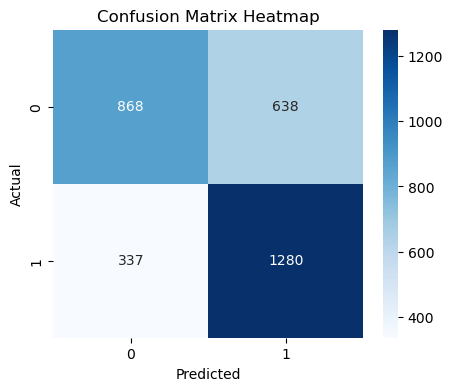

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
# save image
plt.savefig("confusion_matrix.png", bbox_inches='tight')
plt.show()

**Interpretation**:
The confusion matrix shows that out of all predictions, the model correctly classified a large number of restaurants:

868 + 1280 = 2148 correct predictions
638 + 337 = 975 incorrect predictions

This means the model is able to correctly identify most restaurants, especially weak ones, which is important for the business goal. However, there are still some misclassifications where weak restaurants are predicted as non-weak and vice versa, showing that the model is not perfect but reasonably effective.

Overall, the model performs well in distinguishing between weak and non-weak restaurants, with more correct predictions than errors.

## Key Insights:

- The model is able to successfully classify restaurants into Weak and Non-Weak categories based on features like ratings, votes, and pricing.
- The model shows better performance in identifying Weak restaurants (Class 1 recall = 0.79), which is the main business goal.
- Overall accuracy of the model is around 69%, indicating a reasonable predictive performance for real-world use.
- The confusion matrix shows that the model correctly predicts 2148 out of 3123 cases, while misclassifying 975 cases.
- Most errors occur between weak and non-weak boundary cases, meaning some restaurants have mixed or unclear features.

## Conclusion:


The objective of the machine learning model was to predict whether a restaurant is Weak or Non-Weak based on its performance features such as ratings, votes, and pricing.
A Logistic Regression model was trained and evaluated using train-test split. The model achieved an accuracy of approximately 69%, showing reasonable performance in classifying restaurants.
The evaluation results, including the confusion matrix and classification report, indicate that the model is particularly effective in identifying Weak restaurants, which aligns with the main business goal. Some misclassifications are present, but overall the model performs well in distinguishing between weak and non-weak categories.
This model can help Zomato in identifying underperforming restaurants and support data-driven decisions for ranking and improvement.

## Project Summary:

This project analyzes restaurant performance data to understand and predict restaurant quality using both exploratory data analysis and machine learning techniques.

In the EDA phase, restaurants were segmented into categories such as Weak, Hidden Gems, Top Performers, and Overhyped, helping to understand different performance groups in the dataset. Visualizations were used to study patterns in ratings, votes, pricing, and customer engagement.

In the statistical analysis phase, hypothesis testing and ANOVA were performed to identify significant relationships between key features, confirming important patterns observed during EDA.

In the data science phase, the segmentation was simplified into a binary classification problem where Weak = 1 and Non-Weak = 0. A Logistic Regression model was trained using an 80-20 train-test split. The model achieved an accuracy of 68.7% (~69%). Evaluation using confusion matrix and classification report showed that the model is effective in identifying weak restaurants, which is the main business objective.

Overall, this project demonstrates how data segmentation, statistical analysis, and machine learning can work together to help Zomato identify underperforming restaurants and improve ranking and recommendation systems

In [34]:

#Save cleaned dataset to CSV file
df_hyd.to_csv("zomato_hyderabad_cleaned.csv", index=False)
